In [70]:
import pandas as pd

df = pd.read_csv('IPL_data.csv')
df

/tmp/ipykernel_224735/737826771.py:3: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('IPL_data.csv')


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278200,277951,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,2,...,162,116,7,NaN,39,26,0,"('KA Jamieson', 'Shashank Singh')",NaN,False
278201,277952,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,3,...,168,117,7,NaN,45,27,0,"('KA Jamieson', 'Shashank Singh')",NaN,False
278202,277953,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,4,...,172,118,7,NaN,49,28,0,"('KA Jamieson', 'Shashank Singh')",NaN,False
278203,277954,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,5,...,178,119,7,NaN,55,29,0,"('KA Jamieson', 'Shashank Singh')",NaN,False


In [71]:
df.columns

Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='object')

In [72]:
df['final_runs'] = df.groupby(['match_id', 'innings', 'batting_team'])['team_runs'].transform('max')

df_model = df[['match_id', 'season', 'venue', 'batting_team', 'bowling_team', 'ball_no', 'batter', 'runs_batter', 'runs_total', 'runs_target', 'bowler', 'final_runs']]

df_model

,match_id,season,venue,batting_team,bowling_team,ball_no,batter,runs_batter,runs_total,runs_target,bowler,final_runs
0,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.1,SC Ganguly,0,1,NaN,P Kumar,222
1,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.2,BB McCullum,0,0,NaN,P Kumar,222
2,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.3,BB McCullum,0,1,NaN,P Kumar,222
3,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.3,BB McCullum,0,0,NaN,P Kumar,222
4,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.4,BB McCullum,0,0,NaN,P Kumar,222
...,...,...,...,...,...,...,...,...,...,...,...,...
278200,1473511,2025,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bengaluru,19.2,Shashank Singh,0,0,191.0,JR Hazlewood,184
278201,1473511,2025,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bengaluru,19.3,Shashank Singh,6,6,191.0,JR Hazlewood,184
278202,1473511,2025,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bengaluru,19.4,Shashank Singh,4,4,191.0,JR Hazlewood,184
278203,1473511,2025,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bengaluru,19.5,Shashank Singh,6,6,191.0,JR Hazlewood,184


In [73]:
import numpy as np

def over_to_balls(overs):
    over_no = np.floor(overs)
    intra_over_balls = (overs - over_no) * 10

    return (over_no * 6) + intra_over_balls

In [74]:
df_model['balls'] = over_to_balls(df['ball_no']).astype(int)
df_model['balls_left'] = 120 - df_model['balls']

/tmp/ipykernel_224735/1483276181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['balls'] = over_to_balls(df['ball_no']).astype(int)
/tmp/ipykernel_224735/1483276181.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['balls_left'] = 120 - df_model['balls']


In [75]:
df_model['current_score']= df['team_runs']
df_model['wickets'] = 10 - df['team_wicket']
df_model

/tmp/ipykernel_224735/2974113062.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['current_score']= df['team_runs']
/tmp/ipykernel_224735/2974113062.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['wickets'] = 10 - df['team_wicket']


,match_id,season,venue,batting_team,bowling_team,ball_no,batter,runs_batter,runs_total,runs_target,bowler,final_runs,balls,balls_left,current_score,wickets
0,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.1,SC Ganguly,0,1,NaN,P Kumar,222,1,119,1,10
1,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.2,BB McCullum,0,0,NaN,P Kumar,222,2,118,1,10
2,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.3,BB McCullum,0,1,NaN,P Kumar,222,3,117,2,10
3,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.3,BB McCullum,0,0,NaN,P Kumar,222,3,117,2,10
4,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,0.4,BB McCullum,0,0,NaN,P Kumar,222,4,116,2,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278200,1473511,2025,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bengaluru,19.2,Shashank Singh,0,0,191.0,JR Hazlewood,184,116,4,162,3
278201,1473511,2025,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bengaluru,19.3,Shashank Singh,6,6,191.0,JR Hazlewood,184,117,3,168,3
278202,1473511,2025,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bengaluru,19.4,Shashank Singh,4,4,191.0,JR Hazlewood,184,117,3,172,3
278203,1473511,2025,"Narendra Modi Stadium, Ahmedabad",Punjab Kings,Royal Challengers Bengaluru,19.5,Shashank Singh,6,6,191.0,JR Hazlewood,184,119,1,178,3


In [76]:
batters_runs = df.groupby(['batter'])['runs_batter'].sum()
batter_balls = df['batter'].value_counts()

strike_rate = (batters_runs / batter_balls) * 100

bowlers_runs = df.groupby(['bowler'])['runs_bowler'].sum()
bowlers_balls = df['bowler'].value_counts()

economy = (bowlers_runs / bowlers_balls) * 6

In [77]:
df_model['strike_rate'] = df['batter'].map(strike_rate)
df_model['economy'] = df['bowler'].map(economy)

/tmp/ipykernel_224735/1110982157.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['strike_rate'] = df['batter'].map(strike_rate)
/tmp/ipykernel_224735/1110982157.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['economy'] = df['bowler'].map(economy)


In [78]:
df_model = df_model.dropna(subset='runs_target')
df_model = df_model.drop(columns=['batter', 'bowler', 'balls', 'match_id', 'runs_batter', 'ball_no', 'runs_total'])
 

In [79]:
df_model.sample(frac=1).reset_index(drop=True)

,season,venue,batting_team,bowling_team,runs_target,final_runs,balls_left,current_score,wickets,strike_rate,economy
0,2011,Himachal Pradesh Cricket Association Stadium,Royal Challengers Bangalore,Kings XI Punjab,233.0,121,113,3,10,115.724245,7.262428
1,2015,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Rajasthan Royals,Sunrisers Hyderabad,128.0,131,61,62,10,121.751754,8.249534
2,2019,Eden Gardens,Mumbai Indians,Kolkata Knight Riders,233.0,198,30,140,5,127.616279,9.112997
3,2025,"Wankhede Stadium, Mumbai",Mumbai Indians,Chennai Super Kings,177.0,177,90,57,10,145.864662,6.966311
4,2025,"Wankhede Stadium, Mumbai",Gujarat Titans,Mumbai Indians,147.0,147,75,46,9,144.292717,8.723454
...,...,...,...,...,...,...,...,...,...,...,...
133898,2016,Maharashtra Cricket Association Stadium,Kolkata Knight Riders,Rising Pune Supergiants,161.0,162,57,79,7,145.592705,7.200000
133899,2011,Nehru Stadium,Royal Challengers Bangalore,Kochi Tuskers Kerala,162.0,162,96,31,9,129.379290,7.564942
133900,2007/08,Sawai Mansingh Stadium,Rajasthan Royals,Kings XI Punjab,167.0,168,76,61,7,134.163209,7.522007
133901,2011,M Chinnaswamy Stadium,Royal Challengers Bangalore,Chennai Super Kings,129.0,129,96,31,9,142.121729,6.930000


In [81]:
# dropping to keep only complete overs
df_overs = df_model[df_model['balls_left'] % 6 == 0].copy()

# Calculate which over each row represents (1-20)
df_overs['over_number'] = df_overs['balls_left'] // 6

print(f"Total end-of-over data points: {len(df_overs)}")
print(f"Overs covered: {df_overs['over_number'].min()} to {df_overs['over_number'].max()}")
print(f"\nSamples per over:")
print(df_overs['over_number'].value_counts().sort_index())
len(df_overs)

Total end-of-over data points: 23161
Overs covered: 0 to 19

Samples per over:
0      468
1      760
2      940
3     1027
4     1074
5     1098
6     1129
7     1149
8     1168
9     1174
10    1174
11    1180
12    1186
13    1188
14    1188
15    1210
16    2420
17    1199
18    1214
19    1215
Name: over_number, dtype: int64


23161

In [83]:
df_overs['season'] = df_overs['season'].astype(str)
df_overs['season'] = df_overs['season'].astype(str)


In [86]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, MinMaxScaler, FunctionTransformer, LabelEncoder
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder

def log_transform(X):
    return np.log1p(X)

# Create label encoder for season
le_season = LabelEncoder()
df_overs['season_encoded'] = le_season.fit_transform(df_overs['season'])
df_overs['season_encoded'] = le_season.transform(df_overs['season'])


num_features = ['current_score', 'strike_rate', 'economy', 'balls_left', 'wickets', 'runs_target']
cat_features = ['batting_team', 'bowling_team', 'venue']
encoded_season = ['season_encoded']
feature_cols = num_features + cat_features + encoded_season

# Create the full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        # Log transform then RobustScale current_score
        ('current_score_pipe', Pipeline([
            ('log', FunctionTransformer(log_transform, validate=True)),
            ('robust', RobustScaler())
        ]), ['current_score']),
        
        # RobustScale strike_rate and economy
        ('robust_features', RobustScaler(), ['strike_rate', 'economy']),
        
        # MinMaxScale balls_left
        ('minmax_features', MinMaxScaler(), ['balls_left']),
        
        # Pass through unchanged
        ('passthrough_num', 'passthrough', ['wickets', 'runs_target']),
        
        # Target encode categorical features
        ('target_encode', TargetEncoder(cols=cat_features), cat_features),
        
        # Pass through season_encoded
        ('passthrough_season', 'passthrough', encoded_season)
    ],
    remainder='drop'
)

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

# Analyze each over separately
for over_num in range(1, 20):  # Overs 1 to 20
    over_data = df_overs[df_overs['over_number'] == over_num]
    
    
    # Split data for this over
    X = over_data[feature_cols]
    y = over_data['final_runs']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Create and train pipeline
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(n_neighbors=5))
    ])
    
    # Train
    full_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = full_pipeline.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Calculate average stats for this over
    avg_balls_left = over_data['balls_left'].mean()
    avg_current_score = over_data['current_score'].mean()
    avg_wickets = over_data['wickets'].mean()
    
    results.append({
        'over': over_num,
        'balls_left': avg_balls_left,
        'samples': len(over_data),
        'test_samples': len(X_test),
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'avg_current_score': avg_current_score,
        'avg_wickets': avg_wickets
    })
    
    print(f"Over {over_num:2d}: MAE={mae:5.2f}, RMSE={rmse:5.2f}, R²={r2:5.3f}")

results_df = pd.DataFrame(results)
print(f"\n Analysis complete! Analyzed {len(results_df)} overs.")

Over  1: MAE=12.47, RMSE=17.72, R²=0.486
Over  2: MAE=11.74, RMSE=16.87, R²=0.562
Over  3: MAE=13.55, RMSE=20.22, R²=0.512
Over  4: MAE=12.78, RMSE=20.24, R²=0.511
Over  5: MAE=12.90, RMSE=18.42, R²=0.491
Over  6: MAE=13.76, RMSE=20.38, R²=0.506
Over  7: MAE=14.31, RMSE=20.83, R²=0.504
Over  8: MAE=15.03, RMSE=22.20, R²=0.423
Over  9: MAE=15.39, RMSE=23.12, R²=0.373
Over 10: MAE=13.04, RMSE=20.19, R²=0.523
Over 11: MAE=13.48, RMSE=21.21, R²=0.473
Over 12: MAE=13.31, RMSE=20.48, R²=0.528
Over 13: MAE=14.05, RMSE=21.58, R²=0.435
Over 14: MAE=13.44, RMSE=21.36, R²=0.483
Over 15: MAE=12.90, RMSE=19.68, R²=0.606
Over 16: MAE=13.18, RMSE=19.37, R²=0.654
Over 17: MAE=15.75, RMSE=23.29, R²=0.506
Over 18: MAE=17.26, RMSE=25.50, R²=0.370
Over 19: MAE=14.37, RMSE=20.68, R²=0.505

 Analysis complete! Analyzed 19 overs.


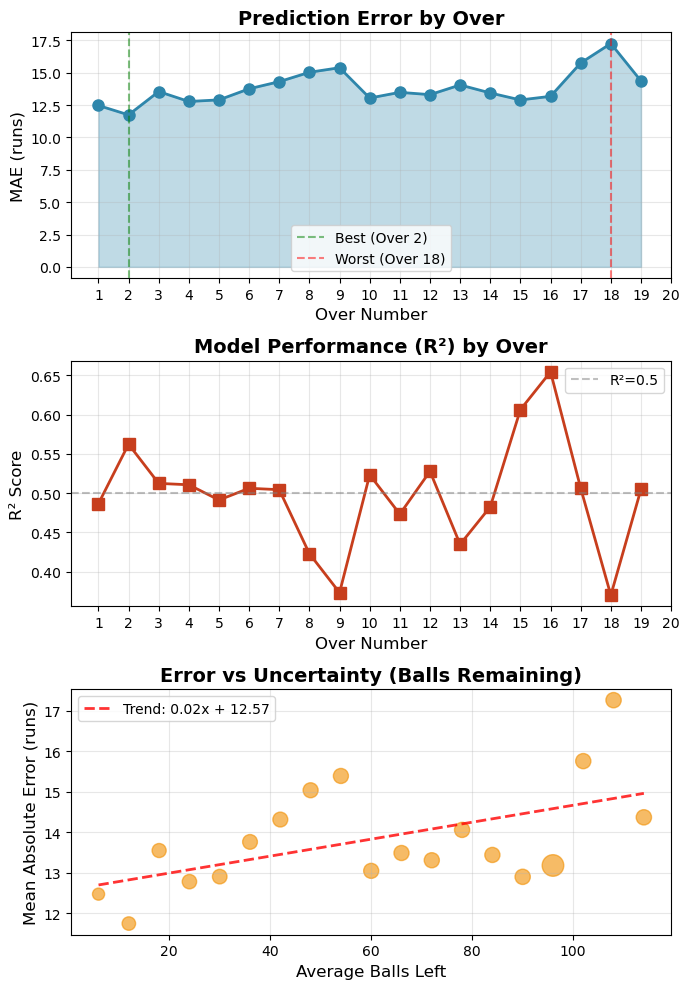

In [108]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(7, 10))

# 1. MAE by Over
axes[0].plot(results_df['over'], results_df['mae'], 
                marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0 ].fill_between(results_df['over'], 0, results_df['mae'], 
                         alpha=0.3, color='#2E86AB')
axes[0].set_xlabel('Over Number', fontsize=12)
axes[0].set_ylabel('MAE (runs)', fontsize=12)
axes[0].set_title('Prediction Error by Over', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 21))

# Highlight best and worst
best_over = results_df.loc[results_df['mae'].idxmin(), 'over']
worst_over = results_df.loc[results_df['mae'].idxmax(), 'over']
axes[0].axvline(best_over, color='green', linestyle='--', alpha=0.5, 
                   label=f'Best (Over {int(best_over)})')
axes[0].axvline(worst_over, color='red', linestyle='--', alpha=0.5,
                   label=f'Worst (Over {int(worst_over)})')
axes[0].legend()

# 2. R² Score by Over
axes[1].plot(results_df['over'], results_df['r2'], 
                marker='s', linewidth=2, markersize=8, color='#C73E1D')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='R²=0.5')
axes[1].set_xlabel('Over Number', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Model Performance (R²) by Over', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, 21))
axes[1].legend()

# 3. MAE vs Balls Left
axes[2].scatter(results_df['balls_left'], results_df['mae'], 
                   s=results_df['samples']/10, alpha=0.6, color='#F18F01')
axes[2].set_xlabel('Average Balls Left', fontsize=12)
axes[2].set_ylabel('Mean Absolute Error (runs)', fontsize=12)
axes[2].set_title('Error vs Uncertainty (Balls Remaining)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
# Add trendline
z = np.polyfit(results_df['balls_left'], results_df['mae'], 1)
p = np.poly1d(z)
axes[2].plot(results_df['balls_left'], p(results_df['balls_left']), 
                "r--", alpha=0.8, linewidth=2, label=f'Trend: {z[0]:.2f}x + {z[1]:.2f}')
axes[2].legend()


plt.tight_layout()
plt.show()